<a href="https://colab.research.google.com/github/merinrose4007/DSA-class-activity/blob/main/Unsupervised_learning_CaseStudy_Merin_Rose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/adult_dataset.csv')

In [3]:
data.duplicated().sum()

np.int64(16)

In [4]:
data = data.drop_duplicates()

In [5]:
data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46384 non-null  float64
 1   workclass       45464 non-null  object 
 2   fnlwgt          48826 non-null  int64  
 3   education       48826 non-null  object 
 4   education-num   48826 non-null  int64  
 5   marital-status  48826 non-null  object 
 6   occupation      45469 non-null  object 
 7   relationship    48826 non-null  object 
 8   race            48826 non-null  object 
 9   sex             48826 non-null  object 
 10  capital-gain    48826 non-null  int64  
 11  capital-loss    48826 non-null  int64  
 12  hours-per-week  46384 non-null  float64
 13  native-country  46121 non-null  object 
 14  income          48826 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.0+ MB


In [7]:
data = data.replace('?', np.nan)

In [8]:
data.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

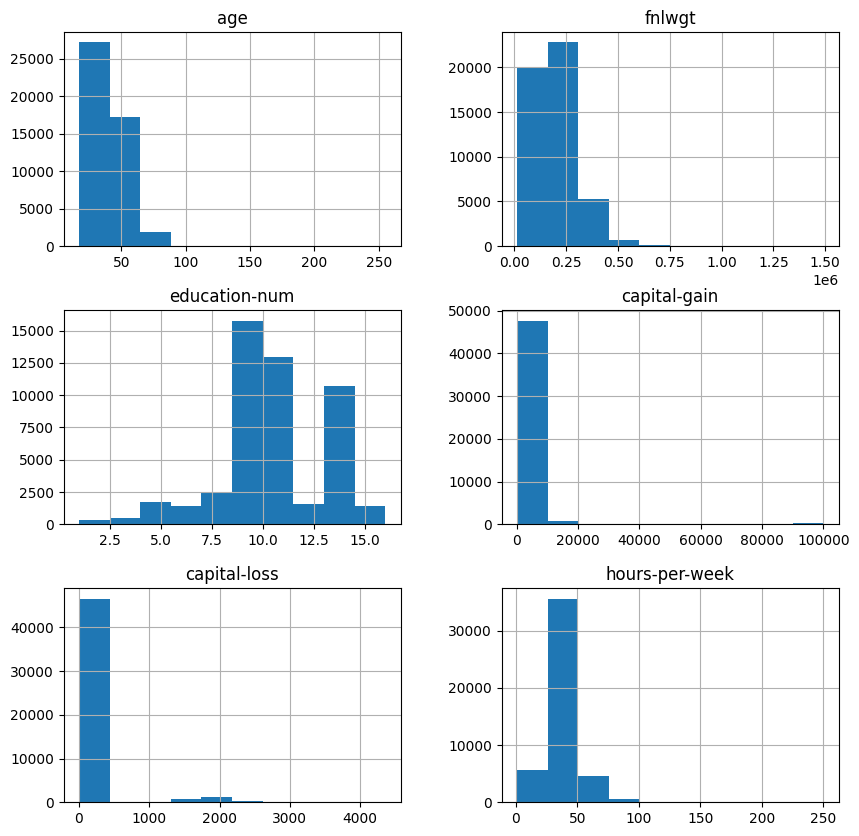

In [9]:
data.hist(figsize=(10,10))

In [10]:
data['hours-per-week'] = data['hours-per-week'].fillna(data['hours-per-week'].median())

In [11]:
data['age'] = data['age'].fillna(data['age'].median())

In [12]:
data['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [13]:
data['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', nan,
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [14]:
data[data['occupation']=='Armed-Forces']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
442,24.0,Federal-gov,191073,HS-grad,9,Never-married,Armed-Forces,Own-child,White,Male,0,0,40.0,United-States,<=50K
1300,29.0,Federal-gov,301010,Some-college,10,Never-married,Armed-Forces,Not-in-family,Black,Male,0,0,60.0,United-States,<=50K
14613,39.0,Federal-gov,227597,HS-grad,9,Never-married,Armed-Forces,Not-in-family,White,Male,0,0,50.0,United-States,<=50K
16111,24.0,Federal-gov,287988,Bachelors,13,Never-married,Armed-Forces,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
18034,34.0,Federal-gov,172716,12th,8,Married-civ-spouse,Armed-Forces,Husband,White,Male,0,0,40.0,United-States,<=50K
18644,23.0,Federal-gov,163870,Some-college,10,Never-married,Armed-Forces,Other-relative,White,Male,0,0,40.0,United-States,<=50K
18769,30.0,Federal-gov,76313,HS-grad,9,Married-civ-spouse,Armed-Forces,Other-relative,Amer-Indian-Eskimo,Male,0,0,48.0,United-States,<=50K
25799,46.0,Federal-gov,344415,Masters,14,Married-civ-spouse,Armed-Forces,Husband,White,Male,0,1887,40.0,United-States,>50K
32316,23.0,Federal-gov,173851,HS-grad,9,Never-married,Armed-Forces,Not-in-family,White,Male,0,0,8.0,United-States,<=50K
32649,24.0,Federal-gov,228724,Some-college,10,Never-married,Armed-Forces,Not-in-family,White,Male,0,0,40.0,United-States,<=50K.


In [15]:
data.loc[data['workclass'].isna() & (data['occupation'] == 'Armed-Forces'), 'workclass'] = 'Federal-gov'

In [16]:
data.loc[data['native-country'].isna() & (data['occupation'] == 'Armed-Forces'), 'native-country'] = 'United-States'

In [17]:
data[data['workclass'] == 'Never-worked']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5361,18.0,Never-worked,206359,10th,6,Never-married,NaN,Own-child,White,Male,0,0,40.0,United-States,<=50K
10845,23.0,Never-worked,188535,7th-8th,4,Divorced,NaN,Not-in-family,White,Male,0,0,35.0,United-States,<=50K
14772,17.0,Never-worked,237272,10th,6,Never-married,NaN,Own-child,White,Male,0,0,30.0,United-States,<=50K
20337,18.0,Never-worked,157131,11th,7,Never-married,NaN,Own-child,White,Female,0,0,10.0,United-States,<=50K
23232,20.0,Never-worked,462294,Some-college,10,Never-married,NaN,Own-child,Black,Male,0,0,40.0,United-States,<=50K
32304,37.0,Never-worked,176673,HS-grad,9,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40.0,United-States,<=50K
32314,18.0,Never-worked,153663,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,4.0,United-States,<=50K
41346,17.0,Never-worked,131593,11th,7,Never-married,NaN,Own-child,Black,Female,0,0,20.0,United-States,<=50K.
46459,18.0,Never-worked,162908,11th,7,Never-married,NaN,Own-child,White,Male,0,0,35.0,United-States,<=50K.


In [18]:
data.loc[data['occupation'].isna() & (data['workclass'] == 'Never-worked'), 'occupation'] = 'No-Occupation'

In [19]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [20]:
data.isna().sum()

,0
age,0
workclass,5124
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5106
relationship,0
race,0
sex,0


In [21]:
data['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', nan,
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [22]:
data[data['workclass'] == 'Local-gov']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
25,56.0,Local-gov,216851,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40.0,United-States,>50K
30,23.0,Local-gov,190709,Assoc-acdm,12,Never-married,Protective-serv,Not-in-family,White,Male,0,0,52.0,NaN,<=50K
79,31.0,Local-gov,125927,7th-8th,4,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40.0,United-States,<=50K
86,49.0,Local-gov,268234,HS-grad,9,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
94,34.0,Local-gov,226296,Bachelors,13,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48789,35.0,Local-gov,297322,Some-college,10,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40.0,United-States,>50K.
48794,29.0,Local-gov,170482,HS-grad,9,Married-civ-spouse,Protective-serv,Husband,Black,Male,0,2057,40.0,United-States,<=50K.
48816,43.0,Local-gov,23157,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1902,50.0,United-States,>50K.
48826,50.0,Local-gov,139347,Masters,14,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,40.0,NaN,>50K.


In [23]:
data['workclass'] = data['workclass'].fillna(data['workclass'].mode()[0])

In [24]:
data['occupation'] = data['occupation'].fillna(data['occupation'].mode()[0])

In [25]:
data['native-country'] = data['native-country'].fillna(data['native-country'].mode()[0])

In [26]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [27]:
num_cols = data.select_dtypes(include = ('float64', 'int64'))
num_cols

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39.0,77516,13,2174,0,40.0
1,50.0,83311,13,0,0,13.0
2,38.0,215646,9,0,0,40.0
3,53.0,234721,7,0,0,40.0
4,28.0,338409,13,0,0,40.0
...,...,...,...,...,...,...
48837,39.0,215419,13,0,0,36.0
48838,64.0,321403,9,0,0,40.0
48839,38.0,374983,13,0,0,50.0
48840,44.0,83891,13,5455,0,40.0


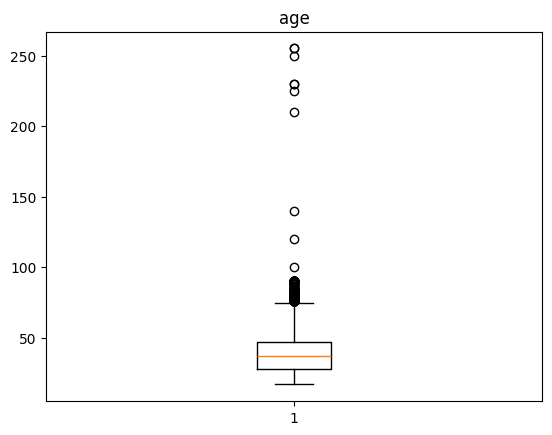

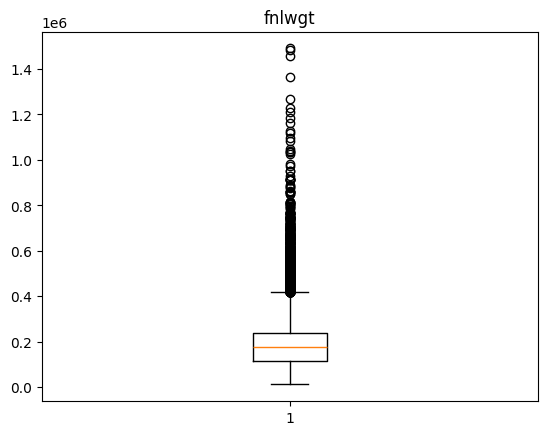

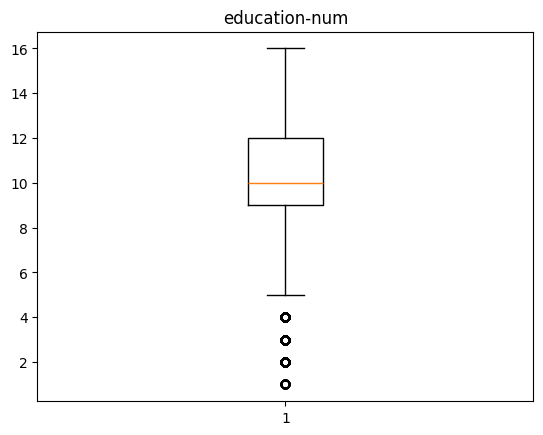

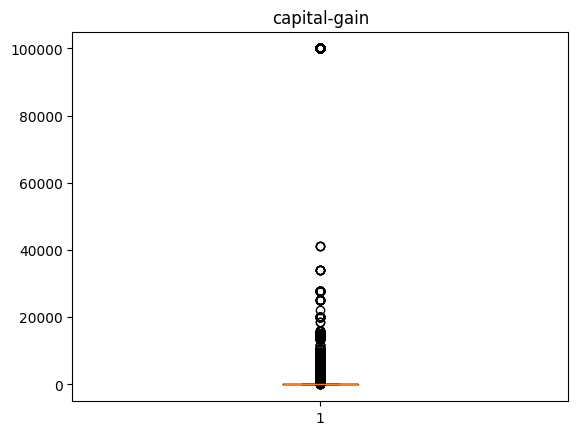

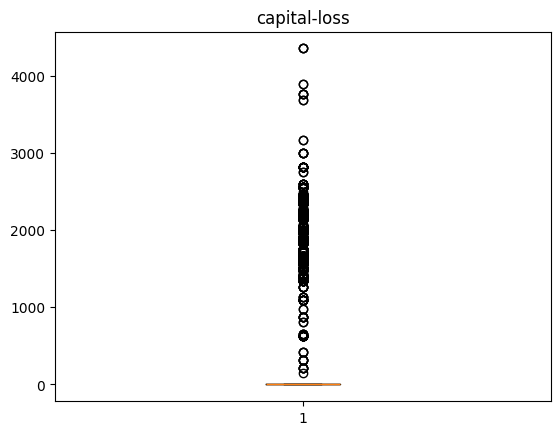

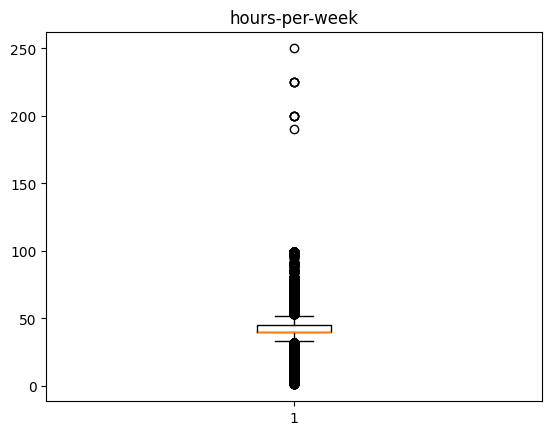

In [28]:
for i in num_cols:
  plt.figure()
  plt.boxplot(data[i])
  plt.title(i)
  plt.show()


In [29]:
from scipy.stats.mstats import winsorize

In [30]:
l = ['age', 'capital-gain', 'hours-per-week']
for i in l:
  data[i] = winsorize(data[i], limits=(0.01, 0.01))

In [31]:
q1 = np.quantile(data['education-num'], 0.25)
q3 = np.quantile(data['education-num'], 0.75)
iqr = q3 - q1
lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)

In [32]:
data['education-num'] = data['education-num'].clip(lower =lower_bound, upper = upper_bound)

In [33]:
data['fnlwgt'] = np.log1p(data['fnlwgt'])

In [34]:
data['capital-loss'] = np.log1p(data['capital-loss'])

In [35]:
data1 =data.copy()

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48826 non-null  float64
 1   workclass       48826 non-null  object 
 2   fnlwgt          48826 non-null  float64
 3   education       48826 non-null  object 
 4   education-num   48826 non-null  float64
 5   marital-status  48826 non-null  object 
 6   occupation      48826 non-null  object 
 7   relationship    48826 non-null  object 
 8   race            48826 non-null  object 
 9   sex             48826 non-null  object 
 10  capital-gain    48826 non-null  int64  
 11  capital-loss    48826 non-null  float64
 12  hours-per-week  48826 non-null  float64
 13  native-country  48826 non-null  object 
 14  income          48826 non-null  object 
dtypes: float64(5), int64(1), object(9)
memory usage: 6.0+ MB


In [37]:
data['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [38]:
data['education'].unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [39]:
data['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [40]:
data['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Mexico', 'South',
       'Puerto-Rico', 'Honduras', 'England', 'Germany', 'Iran',
       'Philippines', 'Italy', 'Columbia', 'Cambodia', 'Thailand',
       'Canada', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'Poland', 'France',
       'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [41]:
data['race'].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

In [42]:
data['relationship'].unique()

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

In [43]:
l = ['occupation', 'marital-status', 'education', 'native-country', 'workclass', 'relationship', 'race']

In [44]:
for i in l:
  freq = data[i].value_counts()
  data[i] = data[i].map(freq)

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
le = LabelEncoder()

In [47]:
data['sex'] = le.fit_transform(data['sex'])

In [48]:
num_cols.corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.073941,0.029412,0.073561,0.056227,0.098979
fnlwgt,-0.073941,1.000000,-0.038681,-0.003702,-0.004359,-0.011041
education-num,0.029412,-0.038681,1.000000,0.125167,0.080977,0.136140
capital-gain,0.073561,-0.003702,0.125167,1.000000,-0.031451,0.079852
capital-loss,0.056227,-0.004359,0.080977,-0.031451,1.000000,0.050909
hours-per-week,0.098979,-0.011041,0.136140,0.079852,0.050909,1.000000


In [49]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [50]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
stand_scaler = MinMaxScaler()
data[['age', 'workclass', 'fnlwgt', 'education', 'education-num','marital-status', 'occupation', 'relationship', 'race','capital-gain', 'capital-loss', 'hours-per-week', 'native-country']] = stand_scaler.fit_transform(data[['age', 'workclass', 'fnlwgt', 'education', 'education-num','marital-status', 'occupation', 'relationship', 'race','capital-gain', 'capital-loss', 'hours-per-week', 'native-country']])

In [51]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.385965,0.050054,0.383890,0.505702,0.739130,0.719248,0.485842,0.607755,1.000000,1,0.144702,0.0,0.444444,1.00000,<=50K
1,0.578947,0.097535,0.398915,0.505702,0.739130,1.000000,0.526215,1.000000,1.000000,1,0.000000,0.0,0.069444,1.00000,<=50K
2,0.368421,1.000000,0.597119,1.000000,0.391304,0.295166,0.179668,0.607755,1.000000,1,0.000000,0.0,0.444444,1.00000,<=50K
3,0.631579,1.000000,0.614784,0.110148,0.217391,1.000000,0.179668,1.000000,0.103505,1,0.000000,0.0,0.444444,1.00000,<=50K
4,0.192982,1.000000,0.691030,0.505702,0.739130,1.000000,1.000000,0.045310,0.103505,0,0.000000,0.0,0.444444,0.00292,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.385965,1.000000,0.596900,0.505702,0.739130,0.295166,1.000000,0.607755,1.000000,0,0.000000,0.0,0.388889,1.00000,<=50K.
48838,0.824561,1.000000,0.680285,1.000000,0.391304,0.066294,1.000000,0.000000,0.103505,1,0.000000,0.0,0.444444,1.00000,<=50K.
48839,0.368421,1.000000,0.712418,0.505702,0.739130,1.000000,1.000000,1.000000,1.000000,1,0.000000,0.0,0.583333,1.00000,<=50K.
48840,0.473684,1.000000,0.400361,0.505702,0.739130,0.295166,0.485842,0.333480,0.026898,1,0.363086,0.0,0.444444,1.00000,<=50K.


In [52]:
X =data[['age', 'occupation', 'hours-per-week', 'sex', 'capital-gain']]

In [53]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmean = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmean.fit(X)
  wcss.append(kmean.inertia_)

In [54]:
wcss

[19984.775782676486,
 9039.058824566975,
 7013.991133120856,
 6184.636922636364,
 5370.649047027829,
 4348.347251712047,
 3958.484457375818,
 3770.407721172862,
 3305.1996189837464,
 3146.2949327877036]

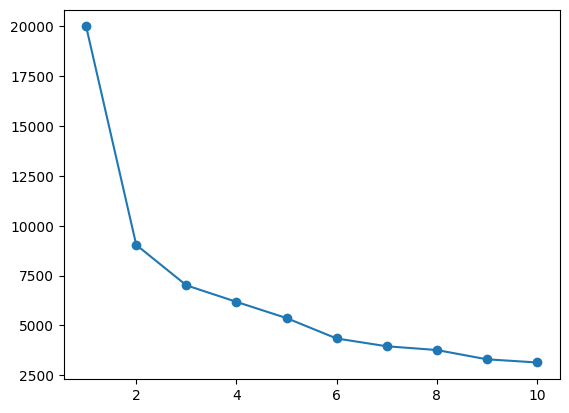

In [55]:
plt.plot(range(1,11), wcss, marker ='o')

In [56]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters = 2, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X)
score = silhouette_score(X, labels)
print(score)

0.5381986248661013


In [57]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
kmeans.fit(X)
data1['Cluster'] = kmeans.labels_
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.385965,0.050054,0.383890,0.505702,0.739130,0.719248,0.485842,0.607755,1.000000,1,0.144702,0.0,0.444444,1.00000,<=50K
1,0.578947,0.097535,0.398915,0.505702,0.739130,1.000000,0.526215,1.000000,1.000000,1,0.000000,0.0,0.069444,1.00000,<=50K
2,0.368421,1.000000,0.597119,1.000000,0.391304,0.295166,0.179668,0.607755,1.000000,1,0.000000,0.0,0.444444,1.00000,<=50K
3,0.631579,1.000000,0.614784,0.110148,0.217391,1.000000,0.179668,1.000000,0.103505,1,0.000000,0.0,0.444444,1.00000,<=50K
4,0.192982,1.000000,0.691030,0.505702,0.739130,1.000000,1.000000,0.045310,0.103505,0,0.000000,0.0,0.444444,0.00292,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.385965,1.000000,0.596900,0.505702,0.739130,0.295166,1.000000,0.607755,1.000000,0,0.000000,0.0,0.388889,1.00000,<=50K.
48838,0.824561,1.000000,0.680285,1.000000,0.391304,0.066294,1.000000,0.000000,0.103505,1,0.000000,0.0,0.444444,1.00000,<=50K.
48839,0.368421,1.000000,0.712418,0.505702,0.739130,1.000000,1.000000,1.000000,1.000000,1,0.000000,0.0,0.583333,1.00000,<=50K.
48840,0.473684,1.000000,0.400361,0.505702,0.739130,0.295166,0.485842,0.333480,0.026898,1,0.363086,0.0,0.444444,1.00000,<=50K.


In [58]:
data['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [59]:
data[data['income'] == '<=50K'].head(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.385965,0.050054,0.383890,0.505702,0.739130,0.719248,0.485842,0.607755,1.000000,1,0.144702,0.000000,0.444444,1.000000,<=50K
1,0.578947,0.097535,0.398915,0.505702,0.739130,1.000000,0.526215,1.000000,1.000000,1,0.000000,0.000000,0.069444,1.000000,<=50K
2,0.368421,1.000000,0.597119,1.000000,0.391304,0.295166,0.179668,0.607755,1.000000,1,0.000000,0.000000,0.444444,1.000000,<=50K
3,0.631579,1.000000,0.614784,0.110148,0.217391,1.000000,0.179668,1.000000,0.103505,1,0.000000,0.000000,0.444444,1.000000,<=50K
4,0.192982,1.000000,0.691030,0.505702,0.739130,1.000000,1.000000,0.045310,0.103505,0,0.000000,0.000000,0.444444,0.002920,<=50K
5,0.350877,1.000000,0.654927,0.163980,0.826087,1.000000,0.526215,0.045310,1.000000,0,0.000000,0.000000,0.444444,1.000000,<=50K
6,0.561404,1.000000,0.535162,0.042874,0.043478,0.026455,0.424278,0.607755,0.103505,0,0.000000,0.000000,0.111111,0.002251,<=50K
12,0.105263,1.000000,0.478873,0.505702,0.739130,0.719248,0.485842,0.333480,1.000000,0,0.000000,0.000000,0.305556,1.000000,<=50K
13,0.263158,1.000000,0.586588,0.096706,0.652174,0.719248,0.476982,0.607755,0.103505,1,0.000000,0.000000,0.583333,1.000000,<=50K
15,0.298246,1.000000,0.624130,0.055552,0.000000,1.000000,0.203599,1.000000,0.001548,1,0.000000,0.000000,0.513889,0.020170,<=50K


In [60]:
data1['income'] = data1['income'].replace('<=50K.', '<=50K')

In [61]:
data1['income'] = data1['income'].replace('>50K.', '>50K')

In [62]:
data1['Cluster'].value_counts()

,count
Cluster,
0,32641
1,16185


In [63]:
data1['income'].value_counts()

,count
income,
<=50K,37139
>50K,11687


In [64]:
summary = data1.groupby('Cluster')[['age', 'hours-per-week', 'capital-gain']].mean()
print(summary)

               age  hours-per-week  capital-gain
Cluster                                         
0        39.335069       42.224748    752.297264
1        36.880259       36.584059    371.207476


In [65]:
summary = data1.groupby('Cluster')[[ 'sex']].apply(lambda x: x.mode().iloc[0])

In [66]:
summary

,sex
Cluster,
0,Male
1,Female


In [67]:
from scipy.cluster.hierarchy import dendrogram, linkage
merging = linkage(X, method = 'ward')
plt.figure(figsize=(10,5))
plt.axhline(y = 6, ls = '--')
dendrogram(merging,)
plt.show

KeyboardInterrupt: 

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
new_cluster_labels = agg_hc.fit_predict(X)
new_cluster_labels

In [ ]:
score = silhouette_score(X, new_cluster_labels)
print(score)

In [ ]:
data1['agg_hc_clusters'] = new_cluster_labels
data1.head()

In [ ]:
data1['agg_hc_clusters'].value_counts()